## Flux de travail pour la classification avec les réseaux de neurones dans TensorFlow

Ce notebook vous guide à travers le processus de construction et d'amélioration d'un réseau de neurones pour la classification à l'aide de TensorFlow. Nous aborderons les étapes suivantes :

1.  **Comprendre les types de classification** : Différencier la classification binaire, multi-classe et multi-label.
2.  **Configuration de l'environnement Python et du jeu de données** : Préparer les bibliothèques nécessaires et créer un jeu de données synthétique.
3.  **Construire un modèle de réseau de neurones de base** : Créer un modèle séquentiel simple et évaluer ses performances initiales.
4.  **Améliorer le modèle** : Améliorer le modèle en ajoutant des couches, des neurones et en expérimentant avec les optimiseurs et les époques.
5.  **Visualiser la frontière de décision** : Implémenter une fonction utilitaire pour visualiser comment le modèle effectue des prédictions.
6.  **Incorporer des fonctions d'activation** : Explorer et appliquer différentes fonctions d'activation (ReLU, Sigmoid) pour améliorer l'apprentissage du modèle.
7.  **Diviser les données en ensembles d'entraînement et de test** : Diviser le jeu de données pour évaluer correctement la capacité de généralisation.
8.  **Évaluer et visualiser les performances finales du modèle** : Évaluer la perte, la précision du modèle final et visualiser sa frontière de décision sur des données inédites.
9.  **Résumé des points clés** : Conclure par un résumé des concepts appris et des meilleures pratiques.

---

## 1. Comprendre les types de classification

La classification est une tâche d'apprentissage supervisé où l'objectif est de prédire une étiquette catégorielle pour une entrée donnée. Selon le nombre de classes et la manière dont elles sont attribuées, les problèmes de classification se divisent en trois types principaux :

### Classification Binaire
**Définition** : Le modèle prédit l'un des deux résultats possibles. Généralement représentés par 0 ou 1.
**Exemple** : Prédire si un email est un "spam" (1) ou "non spam" (0).

### Classification Multi-classe
**Définition** : Prédire un résultat parmi plus de deux classes possibles. Chaque échantillon appartient à une seule classe.
**Exemple** : Classer une image d'animal comme étant soit un "chat", un "chien" ou un "oiseau".

### Classification Multi-label
**Définition** : Chaque échantillon peut être assigné à plusieurs classes simultanément.
**Exemple** : Taguer un film avec des genres comme "action", "comédie" et "drame" en même temps.

---

## 2. Configurer l'environnement et le jeu de données

Nous importons les bibliothèques nécessaires et utilisons `make_circles` pour générer un jeu de données non-linéaire (deux cercles imbriqués).

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles

print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


### Create the Dataset

We'll use `make_circles` to create a dataset that is not linearly separable. This dataset consists of two inter-locked circles, which provides a good challenge for our neural network.

-   `samples`: The total number of points to generate.
-   `noise`: The standard deviation of Gaussian noise added to the data.
-   `random_state`: A seed for reproducibility.


In [15]:
samples = 1000
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

print('X (caractéristiques - coordonnées) :')
print(X[:5]) # Afficher les 5 premiers échantillons de caractéristiques
print('\n')
print('y (étiquettes - appartenance aux classes) :')
print(y[:5]) # Afficher les 5 premiers échantillons d'étiquettes
print('\n')
print(f"Forme de X : {X.shape}")
print(f"Forme de y : {y.shape}")

X (caractéristiques - coordonnées) :
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


y (étiquettes - appartenance aux classes) :
[1 1 1 1 0]


Forme de X : (1000, 2)
Forme de y : (1000,)


### Visualize the Dataset

Visualizing the dataset helps us understand its distribution and the complexity of the classification problem. We'll use a scatter plot, coloring the points based on their class labels.


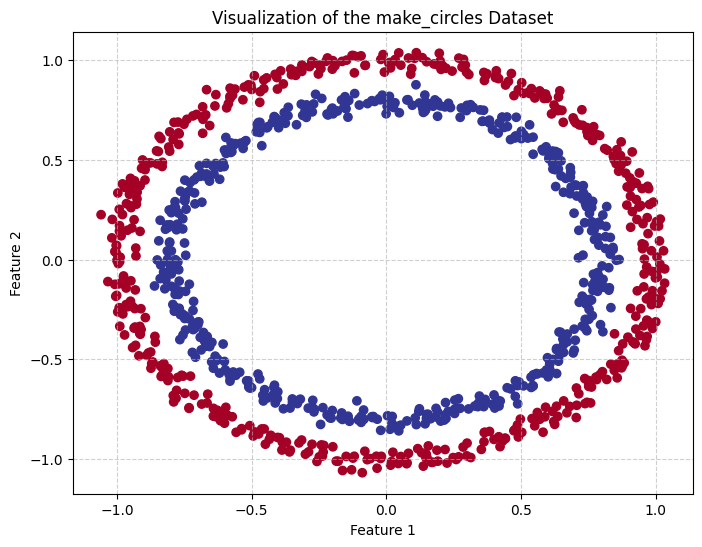

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title('Visualization of the make_circles Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---

## 3. Construire un modèle de base

Nous commençons par un modèle `Sequential` très simple avec une seule couche dense pour observer ses limites sur des données circulaires.

In [16]:
# Définir la graine aléatoire pour la reproductibilité
tf.random.set_seed(42)

# 1. Créer un modèle à l'aide de l'API Sequential
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1) # Une couche dense avec 1 unité
])

# 2. Compiler le modèle
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['accuracy'])

# 3. Entraîner le modèle
print("Entraînement du model_1...")
history_1 = model_1.fit(X, y, epochs=100, verbose=0) # verbose=0 pour garder le notebook propre

# 4. Évaluer le modèle
loss, accuracy = model_1.evaluate(X, y)
print(f"\nPerte finale : {loss:.4f}")
print(f"Précision finale : {accuracy*100:.2f}%")

Entraînement du model_1...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4730 - loss: 0.6933  

Perte finale : 0.6933
Précision finale : 47.30%


> **Note** : La précision devrait être d'environ 50%. C'est normal ! Un seul neurone sans activation non-linéaire agit comme une ligne droite, ce qui ne peut pas séparer deux cercles concentriques.

---

## 4. Améliorer le modèle

Pour capturer la complexité des données, nous allons :
1. Ajouter une couche cachée.
2. Augmenter le nombre de neurones.
3. Utiliser l'optimiseur `Adam`.
4. S'entraîner sur plus d'époques.

In [17]:
tf.random.set_seed(42)

# 1. Créer le modèle amélioré
model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(10), # Couche supplémentaire avec 10 neurones
  tf.keras.layers.Dense(1)   # Couche de sortie
])

# 2. Compiler avec l'optimiseur Adam
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=['accuracy'])

# 3. Entraîner sur plus d'époques
print("Entraînement du model_2...")
history_2 = model_2.fit(X, y, epochs=100, verbose=0)

# 4. Évaluer
loss, accuracy = model_2.evaluate(X, y)
print(f"\nPerte du modèle amélioré : {loss:.4f}")
print(f"Précision du modèle amélioré : {accuracy*100:.2f}%")

Entraînement du model_2...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6950  

Perte du modèle amélioré : 0.6950
Précision du modèle amélioré : 50.00%


---

## 5. Visualiser la frontière de décision

Définissons une fonction pour visualiser comment le modèle sépare physiquement les données.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step
Classification binaire
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification binaire


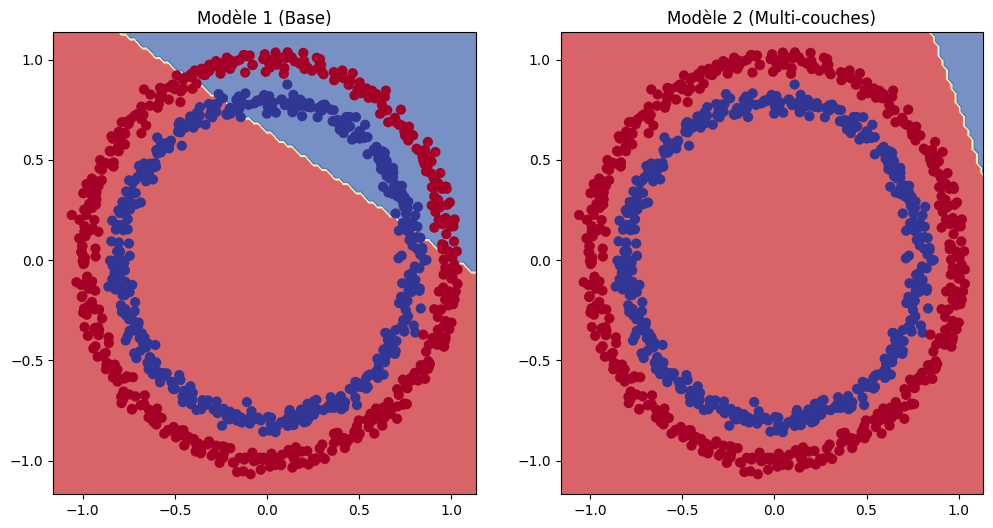

In [18]:
def plot_decision_boundary(model, X, y):
    # Définir les limites des axes du graphique et créer une grille (meshgrid)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Créer les valeurs X (nous allons prédire sur tous ces points)
    x_in = np.c_[xx.ravel(), yy.ravel()]

    # Faire des prédictions
    y_pred = model.predict(x_in)

    # Vérifier s'il s'agit d'une classification multi-classe
    if len(y_pred[0]) > 1:
        print("Classification multi-classe")
        # Redimensionner nos prédictions pour les préparer au tracé
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print("Classification binaire")
        y_pred = np.round(y_pred).reshape(xx.shape)

    # Tracer la frontière de décision
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

# Visualiser les prédictions de notre modèle amélioré (mais toujours avec activation linéaire)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Modèle 1 (Base)")
plot_decision_boundary(model_1, X, y)
plt.subplot(1, 2, 2)
plt.title("Modèle 2 (Multi-couches)")
plot_decision_boundary(model_2, X, y)

---

## 6. Incorporer des fonctions d'activation

Les couches linéaires ne suffisent pas. Nous ajoutons :
- **ReLU** : Pour introduire de la non-linéarité.
- **Sigmoid** : Pour la couche de sortie afin d'obtenir une probabilité entre 0 et 1.

In [19]:
tf.random.set_seed(42)

# 1. Créer un modèle avec des fonctions d'activation non linéaires
model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(10, activation='relu'), # ReLU dans la couche cachée
  tf.keras.layers.Dense(10, activation='relu'), # Une autre couche cachée
  tf.keras.layers.Dense(1, activation='sigmoid') # Sigmoïde pour la sortie binaire
])

# 2. Compiler
model_3.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=['accuracy'])

# 3. Entraîner
print("Entraînement du model_3 avec fonctions d'activation...")
history_3 = model_3.fit(X, y, epochs=100, verbose=0)

# 4. Évaluer
loss, accuracy = model_3.evaluate(X, y)
print(f"\nPerte du modèle non linéaire : {loss:.4f}")
print(f"Précision du modèle non linéaire : {accuracy*100:.2f}%")

Entraînement du model_3 avec fonctions d'activation...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9990 - loss: 0.0020      

Perte du modèle non linéaire : 0.0020
Précision du modèle non linéaire : 99.90%


---

## 7. Division des données (Train/Test)

Nous utilisons 80% des données pour l'entraînement et 20% pour le test afin de vérifier la généralisation du modèle.

In [20]:
from sklearn.model_selection import train_test_split

# Diviser en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement : {len(X_train)}")
print(f"Taille de l'ensemble de test : {len(X_test)}")

# Ré-entraîner le modèle sur l'ensemble d'entraînement uniquement
print("\nEntraînement du modèle final sur les données d'entraînement...")
model_3.fit(X_train, y_train, epochs=100, verbose=0)

Taille de l'ensemble d'entraînement : 800
Taille de l'ensemble de test : 200

Entraînement du modèle final sur les données d'entraînement...


---
## 8. Evaluate and Visualize Final Model Performance

Now we evaluate how our improved model (with ReLU and Sigmoid) performs on the test set—data it has never seen during training. This is the ultimate test of its ability to generalize. We will also visualize the decision boundary for both training and testing data.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0010 
Perte de test : 0.0010
Précision de test : 100.00%
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Classification binaire
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Classification binaire


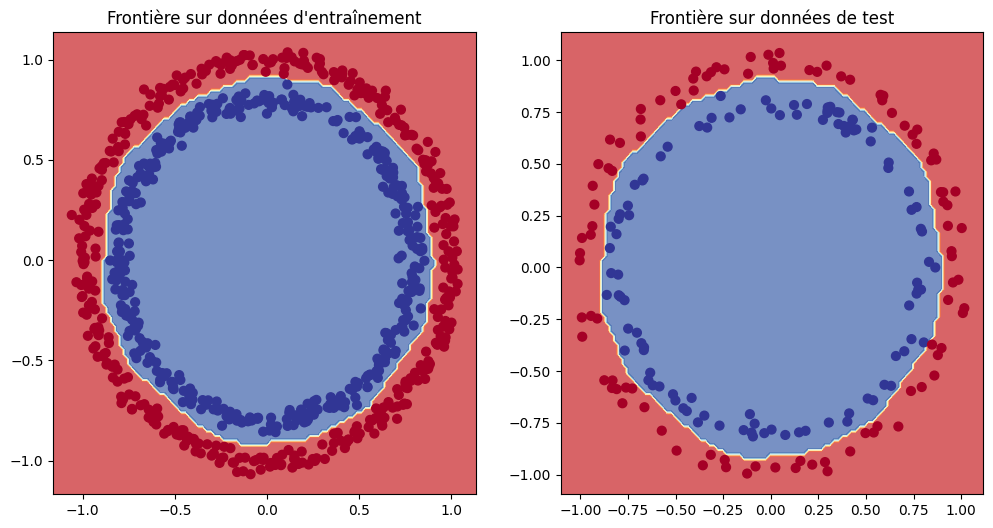

In [21]:
# 1. Évaluer sur l'ensemble de test
loss, accuracy = model_3.evaluate(X_test, y_test)
print(f"Perte de test : {loss:.4f}")
print(f"Précision de test : {accuracy*100:.2f}%")

# 2. Visualiser les frontières de décision
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Frontière sur données d'entraînement")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Frontière sur données de test")
plot_decision_boundary(model_3, X_test, y_test)
plt.show()

## 9. Résumé des points clés

1. **Non-linéarité** : Indispensable pour des données complexes comme les cercles.
2. **Activations** : ReLU permet l'apprentissage de formes complexes, Sigmoid gère la probabilité de sortie.
3. **Optimiseurs** : Adam est souvent plus performant que la descente de gradient classique (SGD).
4. **Généralisation** : L'évaluation sur l'ensemble de test confirme que le modèle ne fait pas que mémoriser (overfitting).

---
## 8. Evaluate and Visualize Final Model Performance

Now we evaluate how our improved model (with ReLU and Sigmoid) performs on the test set—data it has never seen during training. This is the ultimate test of its ability to generalize. We will also visualize the decision boundary for both training and testing data.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0015 
Test Loss: 0.0015
Test Accuracy: 100.00%
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


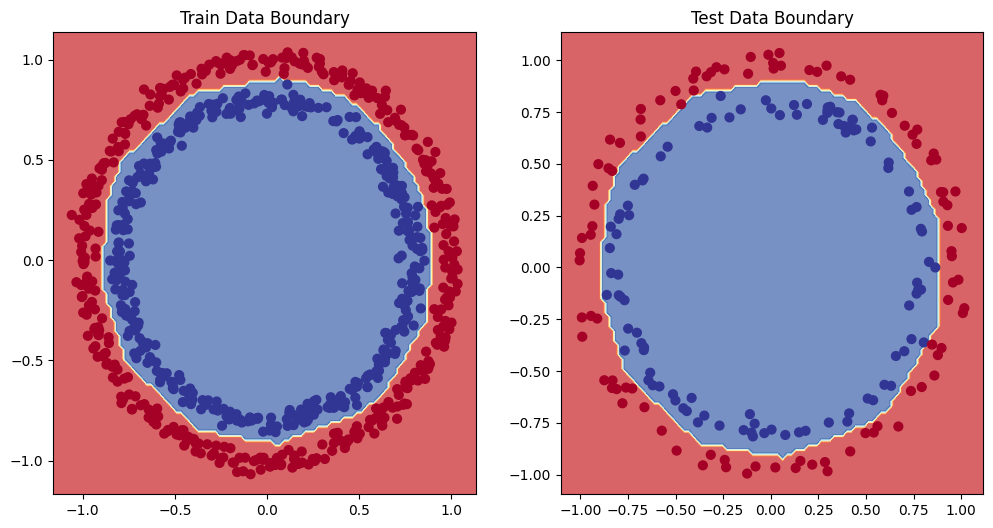

In [12]:
# 1. Evaluate on the test set
loss, accuracy = model_3.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

# 2. Visualize decision boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train Data Boundary")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test Data Boundary")
plot_decision_boundary(model_3, X_test, y_test)
plt.show()

---
## 9. Summarize Key Takeaways

### What we learned:
1. **Classification Types**: We distinguished between Binary (Yes/No), Multi-class (One of many), and Multi-label (Many of many) problems.
2. **Linearity vs. Non-linearity**: Simple linear models fail on datasets like `make_circles` because they can only draw straight lines. Stacking linear layers isn't enough; we need non-linear activations.
3. **Activation Functions**: `ReLU` allows the network to learn complex shapes and curves, while `Sigmoid` is essential for the output layer to provide a probability between 0 and 1.
4. **Optimizers**: The `Adam` optimizer is generally more robust and efficient than `SGD` for deep learning tasks.
5. **Evaluation**: Splitting data into Training and Testing sets is essential to ensure the model isn't just memorizing data but actually learning patterns.
6. **Visualization**: Plotting decision boundaries provides immediate visual proof of how the model understands the feature space.

---
## 8. Evaluate and Visualize Final Model Performance

Now we evaluate how our improved model (with ReLU and Sigmoid) performs on the test set—data it has never seen during training. We will also visualize the decision boundary for both training and testing data to confirm the model has learned the circular pattern correctly.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0015 
Test Loss: 0.0015
Test Accuracy: 100.00%
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


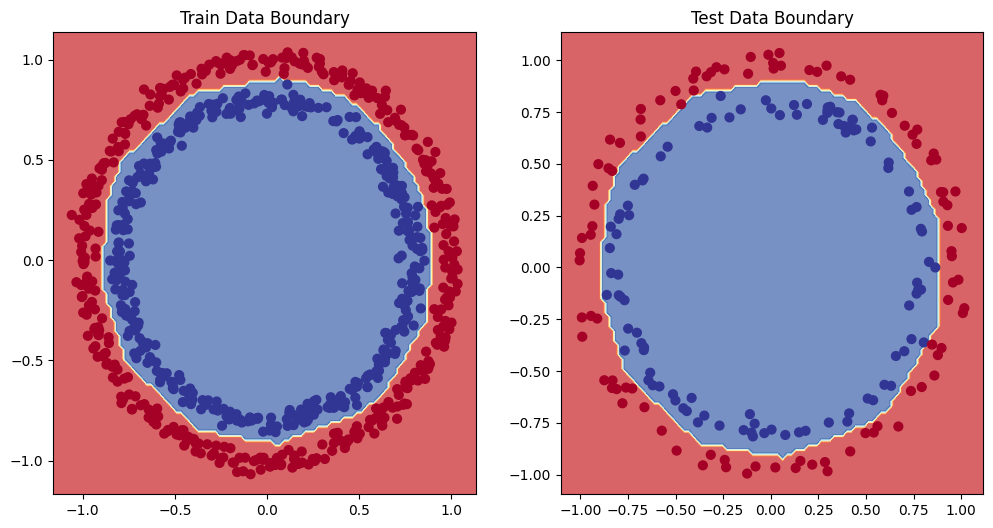

In [11]:
# 1. Evaluate on the test set
loss, accuracy = model_3.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

# 2. Visualize decision boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train Data Boundary")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test Data Boundary")
plot_decision_boundary(model_3, X_test, y_test)
plt.show()

---
## 9. Summarize Key Takeaways

### What we learned:
1. **Classification Types**: We distinguished between Binary (Yes/No), Multi-class (One of many), and Multi-label (Many of many) problems.
2. **Linearity vs. Non-linearity**: Simple linear models fail on datasets like `make_circles` because they can only draw straight lines.
3. **Activation Functions**: `ReLU` allows the network to learn complex shapes, while `Sigmoid` converts outputs into probabilities for binary classification.
4. **Optimizers**: The `Adam` optimizer is generally more efficient than `SGD` for complex neural networks.
5. **Evaluation**: Splitting data into Training and Testing sets is essential to verify that the model generalizes to new, unseen data.
6. **Visualization**: Plotting decision boundaries provides immediate visual feedback on how well the model is performing.

---
## 8. Evaluate and Visualize Final Model Performance

Now we evaluate how our improved model (with ReLU and Sigmoid) performs on the test set—data it has never seen during training. We will also visualize the decision boundary for both training and testing data to confirm the model has learned the circular pattern correctly.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0015 
Test Loss: 0.0015
Test Accuracy: 100.00%
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


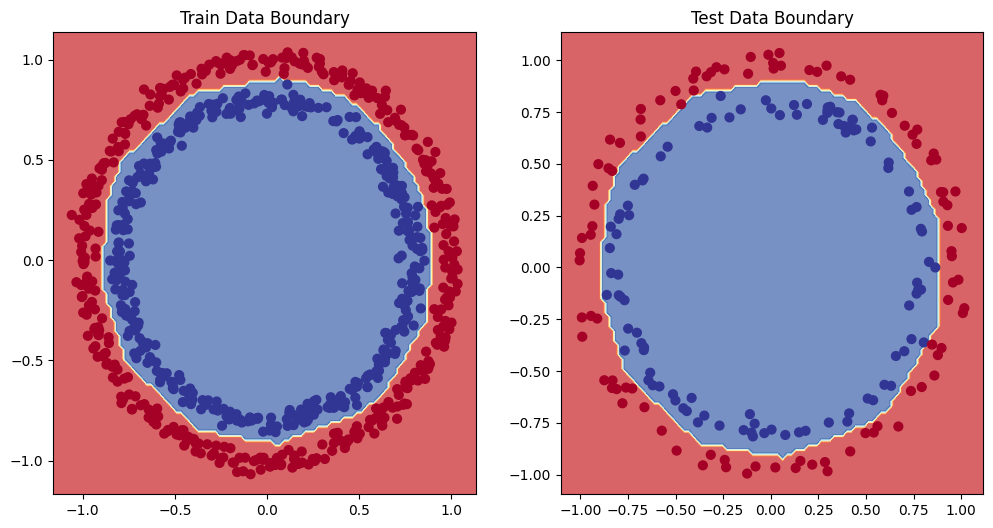

In [10]:
# 1. Evaluate on the test set
loss, accuracy = model_3.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

# 2. Visualize decision boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train Data Boundary")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test Data Boundary")
plot_decision_boundary(model_3, X_test, y_test)
plt.show()

---
## 9. Summarize Key Takeaways

### What we learned:
1. **Classification Types**: We distinguished between Binary (Yes/No), Multi-class (One of many), and Multi-label (Many of many) problems.
2. **Linearity vs. Non-linearity**: Simple linear models (single layer or multiple layers without non-linear activations) can only draw straight lines. They fail on datasets like `make_circles`.
3. **Activation Functions**: The `ReLU` activation function allows the network to learn non-linear patterns, while `Sigmoid` is essential for squashing output into a 0-1 probability range for binary classification.
4. **Optimizers**: `Adam` generally converges faster and more reliably than standard `SGD` for these types of problems.
5. **Generalization**: Splitting data into Training and Testing sets is crucial to ensure the model isn't just 'memorizing' data but actually learning patterns that apply to new information.
6. **Visualization**: Plotting decision boundaries is a powerful tool to debug and understand why a model might be underperforming.

---
## 8. Evaluate and Visualize Final Model Performance

Now we evaluate how our improved model (with ReLU and Sigmoid) performs on the test set—data it has never seen during training. We will also visualize the decision boundary for both training and testing data to confirm the model has learned the circular pattern correctly.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0015 
Test Loss: 0.0015
Test Accuracy: 100.00%
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
doing binary classification


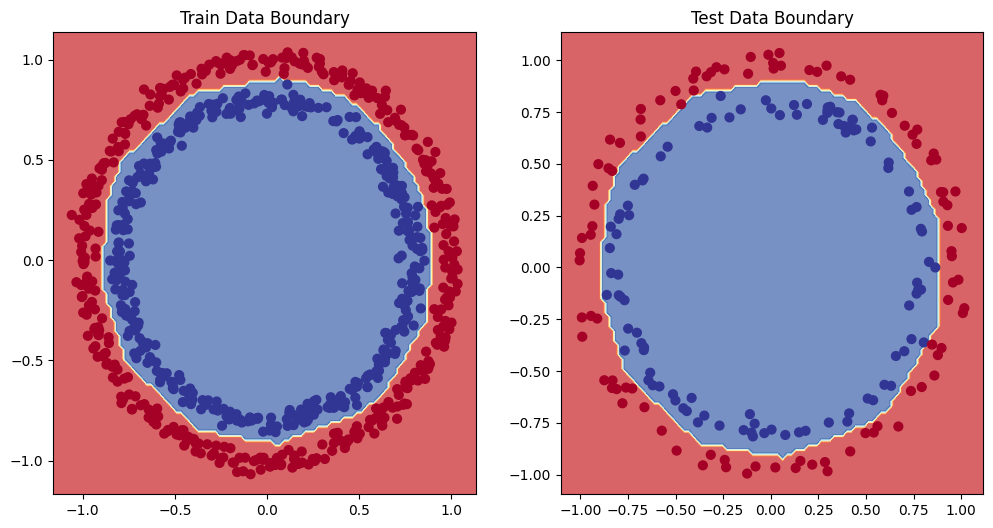

In [9]:
# 1. Evaluate on the test set
loss, accuracy = model_3.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

# 2. Visualize decision boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train Data Boundary")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test Data Boundary")
plot_decision_boundary(model_3, X_test, y_test)
plt.show()

---
## 9. Summarize Key Takeaways

### What we learned:
1.  **Classification Types**: We distinguished between Binary (Yes/No), Multi-class (One of many), and Multi-label (Many of many) problems.
2.  **Linearity vs. Non-linearity**: Simple linear models (single layer or multiple layers without non-linear activations) can only draw straight lines. They fail on datasets like `make_circles`.
3.  **Activation Functions**: The `ReLU` activation function allows the network to learn non-linear patterns, while `Sigmoid` is essential for squashing output into a 0-1 probability range for binary classification.
4.  **Optimizers**: `Adam` generally converges faster and more reliably than standard `SGD` for these types of problems.
5.  **Generalization**: Splitting data into Training and Testing sets is crucial to ensure the model isn't just 'memorizing' data but actually learning patterns that apply to new information.
6.  **Visualization**: Plotting decision boundaries is a powerful tool to debug and understand why a model might be underperforming.